<a href="https://colab.research.google.com/github/Aranzazu21/Hands-on-1-2/blob/master/Hands_on_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Multi-layer Perceptron for Image Classificaction**

* **Jorge limon aranzazu**
* **220111773**


# **Pipeline del Proyecto: Configuración del Entorno**

En esta primera celda, preparamos el motor computacional de nuestro proyecto importando las herramientas de **Scikit-Learn** y **Pandas**. Cada librería importada cumple una función crítica en el flujo de trabajo de la Red Neuronal:

* **Pandas (`pd`) y NumPy (`np`):** Esenciales para la manipulación de estructuras de datos y operaciones matriciales necesarias en el entrenamiento.
* **`preprocessing`:** Contiene las herramientas para transformar datos categóricos en formatos numéricos procesables.
* **`train_test_split`:** Permite dividir el dataset para garantizar que el modelo sea evaluado con datos que nunca ha visto, evitando el sobreajuste (*overfitting*).
* **`StandardScaler`:** Herramienta fundamental para la normalización de las variables, asegurando que todas las entradas tengan el mismo peso matemático.
* **`MLPClassifier`:** Es el corazón del proyecto; la implementación del **Perceptrón Multicapa** con soporte para *Backpropagation*.
* **`classification_report` y `confusion_matrix`:** Métricas de diagnóstico para medir la precisión y eficacia de la clasificación final.

In [9]:
# Celda de Código: Importación y Carga de Datos
import pandas as pd
import numpy as np
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix



### ** Carga del Dataset e Interpretación de Variables**

En esta sección, realizamos la lectura del conjunto de datos **Iris** desde el repositorio oficial de la **UCI**. Este dataset es fundamental para entender la clasificación multiclase. Las variables se interpretan de la siguiente manera:

* **Variables Numéricas (Atributos):** `sepal-length`, `sepal-width`, `petal-length` y `petal-width`. Representan las dimensiones físicas de las flores en centímetros (cm).
* **Variable Categórica (Clase):** La columna `Class` identifica la especie de la flor (*Setosa, Versicolor o Virginica*). Es el objetivo que el modelo debe aprender a distinguir.



### ** Variables Independientes y Dependiente**

Para que el Perceptrón Multicapa pueda ser entrenado mediante **Backpropagation**, el código organiza los datos en dos estructuras:

1.  **Variables Independientes ($X$):** Las 4 columnas de medidas físicas. Son las entradas que activarán las neuronas de la capa inicial.
2.  **Variable Dependiente ($y$):** La columna `Class`. Es el valor de referencia o "target" que permitirá calcular el error y ajustar los pesos de la red.

> **Nota:** La visualización mediante `.head()` nos permite confirmar que los nombres de las columnas se han asignado correctamente y que los datos se han importado sin errores de formato.

In [10]:
# Carga del dataset desde la URL oficial
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']
irisdata = pd.read_csv(url, names=names)

# Visualización inicial
print("Primeras 5 filas del dataset:")
print(irisdata.head())

Primeras 5 filas del dataset:
   sepal-length  sepal-width  petal-length  petal-width        Class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa


### ** Codificación de Etiquetas (Label Encoding)**

Para que el **Perceptrón Multicapa (MLP)** pueda realizar cálculos matemáticos y ajustar sus pesos mediante el error, es indispensable separar las variables y transformar los datos textuales en numéricos:

#### **Proceso de Codificación (Label Encoding)**
Utilizamos la herramienta **`LabelEncoder`** para mapear las categorías de texto a valores enteros:
* **0:** Iris-setosa
* **1:** Iris-versicolor
* **2:** Iris-virginica

> **Importancia:** Este paso permite que la función de pérdida del modelo compare la predicción numérica de la red con la etiqueta real, facilitando la ejecución del algoritmo de **Backpropagation**.

In [11]:
# Celda de Código: Selección de variables y codificación
# X: Atributos (todas las filas, columnas de la 0 a la 3)
X = irisdata.iloc[:, 0:4]

# y: Etiquetas (columna 'Class')
y = irisdata['Class']

# Transformación de etiquetas categóricas (texto) a numéricas (0, 1, 2)
le = preprocessing.LabelEncoder()
y = le.fit_transform(y)

print("Clases únicas codificadas:", np.unique(y))

Clases únicas codificadas: [0 1 2]


### ** División del Dataset y Estandarización de los Datos**

En esta fase, preparamos los datos finales antes de alimentar la Red Neuronal. Este proceso se divide en dos pasos críticos:

#### **1. División Train/Test (80/20)**
Dividimos el dataset original para garantizar la integridad del modelo:
* **X_train / y_train (80%):** Datos utilizados para que la MLP aprenda los patrones.
* **X_test / y_test (20%):** Datos "nuevos" que la red nunca ha visto, usados para evaluar su capacidad de generalización.

#### **2. Estandarización con `StandardScaler`**
**¿Por qué es necesario estandarizar?**
Las redes neuronales calculan gradientes basados en los pesos. Si una variable tiene un rango mayor (ej. 7.9 cm) que otra (ej. 0.2 cm), la red dará más importancia a la variable más grande por error. La estandarización transforma los datos para que tengan una **media de 0 y una desviación estándar de 1**.

**¿Cómo funciona?**
Se aplica la fórmula $z = \frac{x - \mu}{\sigma}$ (donde $\mu$ es el promedio y $\sigma$ la desviación).
* **`scaler.fit(X_train)`:** Calcula el promedio y la desviación únicamente del set de entrenamiento.
* **`scaler.transform`:** Aplica la escala tanto a entrenamiento como a prueba para mantener la coherencia matemática.

In [12]:
# Celda de Código: División de datos y Estandarización
# División: 80% para entrenamiento y 20% para pruebas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Aplicación de la estandarización
scaler = StandardScaler()
scaler.fit(X_train) # El escalador aprende la media y desviación del set de entrenamiento

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

print("Ejemplo de datos estandarizados (X_train):")
print(X_train[:3])

Ejemplo de datos estandarizados (X_train):
[[-1.47393679  1.22037928 -1.5639872  -1.30948358]
 [-0.13307079  3.02001693 -1.27728011 -1.04292204]
 [ 1.08589829  0.09560575  0.38562104  0.28988568]]


## **Model Selection: Arquitectura de la MLP**

En esta fase definimos la estructura de nuestra Red Neuronal. La configuración elegida busca un equilibrio entre capacidad de aprendizaje y eficiencia:

* **Capas Ocultas (`hidden_layer_sizes`):** Hemos definido **3 capas ocultas con 10 neuronas cada una** `(10, 10, 10)`. Esta profundidad permite que la red aprenda fronteras de decisión complejas para separar las especies de flores.
* **Iteraciones (`max_iter`):** Se establece en **1000**. Esto define el número máximo de veces que el algoritmo recorrerá el dataset para ajustar los pesos.
* **Random State:** Usamos la semilla `42` para asegurar que los resultados sean reproducibles en cualquier ejecución.



---

## **Model Training: El proceso de aprendizaje**

Al ejecutar la función **`.fit(X_train, y_train)`**, la red inicia un proceso iterativo de "ida y vuelta" conocido como **Entrenamiento**:

1.  **Forward Pass (Pase hacia adelante):** Los datos de las flores entran por la capa inicial, se multiplican por los pesos ($w$), se les suma el sesgo ($b$) y pasan por la función de activación en cada neurona hasta generar una predicción en la capa de salida.
2.  **Cálculo de Pérdida:** Se compara la predicción de la red con la etiqueta real ($y$) para medir qué tan grande es el error.
3.  **Backpropagation (Retropropagación):** El error se propaga hacia atrás a través de las capas. Utilizando derivadas (gradientes), la red ajusta sus pesos para reducir el error en la siguiente iteración.

> **Convergencia:** El entrenamiento finaliza cuando el error es mínimo o se alcanza el límite de 1000 iteraciones.

In [13]:
# Celda de Código: Entrenamiento
# Creamos la instancia del modelo
mlp = MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=1000, random_state=42)

# Entrenamiento del modelo con los datos escalados
mlp.fit(X_train, y_train)

print("Entrenamiento completado.")

Entrenamiento completado.


### ** Model Prediction: Clasificación de nuevos patrones**

Una vez que la Red Neuronal ha sido entrenada, el modelo es capaz de recibir medidas de flores que nunca ha procesado y clasificarlas. Para que esta predicción sea exitosa, los datos deben pasar por el mismo flujo de transformación que los datos de entrenamiento:

#### **El Flujo de la Predicción:**
1.  **Estandarización de la Entrada:** El nuevo patrón (ej. `[5.1, 3.5, 1.4, 0.2]`) debe ser transformado mediante el objeto `scaler`. Esto asegura que los valores estén en la misma escala (media 0, varianza 1) que los pesos aprendidos por la red.
2.  **Inferencia del Modelo:** La función `mlp.predict()` realiza un **Pase hacia adelante (Forward Pass)** a través de las capas de la MLP, calculando la probabilidad de pertenencia a cada una de las 3 clases.
3.  **Decodificación de Etiquetas (`Inverse Transform`):** La red devuelve un número (0, 1 o 2). Utilizamos el objeto `le` (LabelEncoder) para traducir ese número de vuelta a su nombre original (ej. *Iris-setosa*).

> **Validación:** El ejemplo incluido en el código utiliza medidas típicas de una flor **Setosa** para comprobar que la red ha aprendido correctamente las fronteras de decisión.

In [14]:
# Celda de Código: Función de Predicción
def prediccion_personalizada(medidas):
    """
    Recibe una lista con [sepal-length, sepal-width, petal-length, petal-width]
    """
    # 1. Convertir a array y escalar
    entrada = scaler.transform([medidas])

    # 2. Realizar predicción
    pred = mlp.predict(entrada)

    # 3. Traducir número a nombre original
    especie = le.inverse_transform(pred)
    return especie[0]

# Prueba con un patrón de entrada: [5.1, 3.5, 1.4, 0.2] (Típica Setosa)
resultado = prediccion_personalizada([5.1, 3.5, 1.4, 0.2])
print(f"El patrón [5.1, 3.5, 1.4, 0.2] ha sido clasificado como: {resultado}")

El patrón [5.1, 3.5, 1.4, 0.2] ha sido clasificado como: Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## ** Model Evaluation: Análisis de Rendimiento**

Para determinar si nuestra Red Neuronal (MLP) ha aprendido correctamente, es fundamental evaluarla con el **Set de Prueba (X_test)**, que contiene datos que el modelo nunca vio durante el entrenamiento. En esta sección, utilizamos dos herramientas diagnósticas estándar:

### **1. Matriz de Confusión**
Es una tabla que muestra el desempeño del algoritmo. Cada fila representa las instancias de una **clase real**, mientras que cada columna representa las instancias de una **clase predicha**.
* **Diagonal Principal:** Indica los aciertos (Verdaderos Positivos).
* **Fuera de la Diagonal:** Indica en qué especies se está "confundiendo" la red (ej. si clasifica una *Versicolor* como *Virginica*).



### **2. Reporte de Clasificación**
Este reporte desglosa la eficacia de la red mediante tres métricas clave para cada especie:

* **Precisión (Precision):** ¿De todas las flores que la red marcó como *Setosa*, cuántas lo eran realmente? (Evita falsos positivos).
* **Sensibilidad (Recall):** ¿De todas las *Setosas* reales que había, cuántas fue capaz de encontrar la red? (Evita falsos negativos).
* **F1-Score:** Es el promedio armónico entre precisión y sensibilidad; una métrica robusta para saber si el modelo es equilibrado.
* **Exactitud (Accuracy):** El porcentaje total de predicciones correctas sobre el total de muestras.

> **Interpretación:** Un valor cercano a **1.00 (100%)** indica que el Perceptrón Multicapa ha logrado separar casi perfectamente las clases en el espacio multidimensional.

In [15]:
# Celda de Código: Evaluación
# Generar predicciones sobre el set de prueba
y_pred = mlp.predict(X_test)

# Mostrar resultados
print("--- Matriz de Confusión ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

--- Matriz de Confusión ---
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



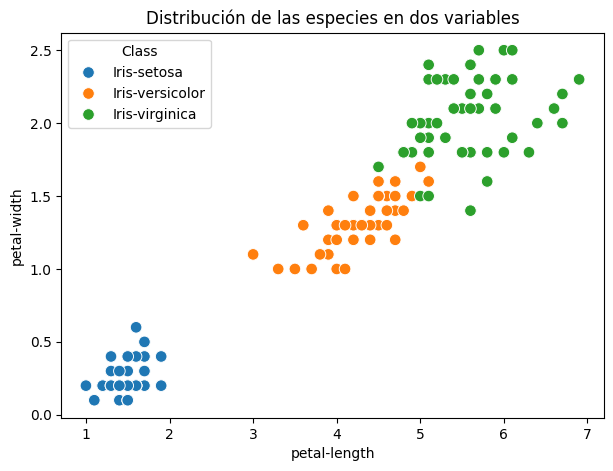

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt



plt.figure(figsize=(7,5))
sns.scatterplot(data=irisdata, x="petal-length", y="petal-width", hue="Class", s=70)
plt.title("Distribución de las especies en dos variables")
plt.show()

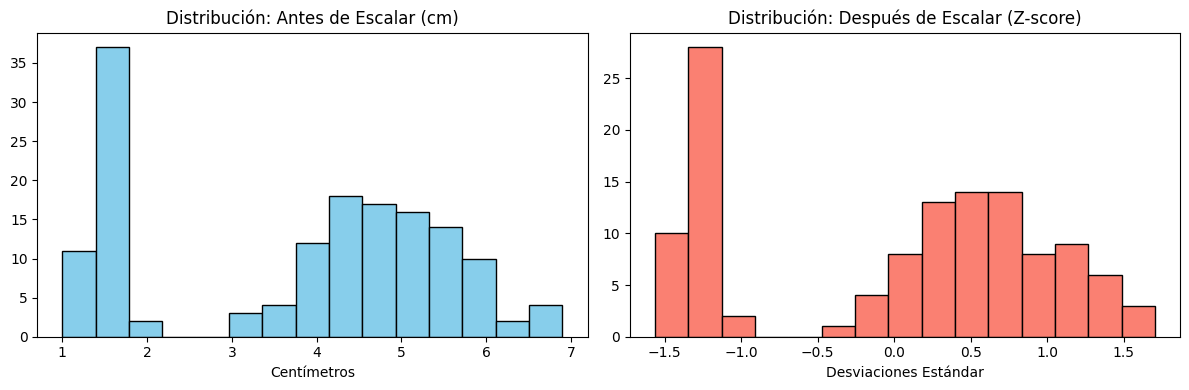

In [18]:
import matplotlib.pyplot as plt

# Creamos la figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(12,4))

# Histograma ANTES de escalar (Usamos X que aún es DataFrame)
# Usamos el nombre de columna 'petal-length' que definiste al inicio
axes[0].hist(X['petal-length'], bins=15, color='skyblue', edgecolor="black")
axes[0].set_title("Distribución: Antes de Escalar (cm)")
axes[0].set_xlabel("Centímetros")

# Histograma DESPUÉS de escalar (Usamos X_train que ya es un Array)
# Como ya no hay nombres de columnas, accedemos por índice.
# 'petal-length' era la tercera columna, por eso usamos el índice [:, 2]
axes[1].hist(X_train[:, 2], bins=15, color='salmon', edgecolor="black")
axes[1].set_title("Distribución: Después de Escalar (Z-score)")
axes[1].set_xlabel("Desviaciones Estándar")

plt.tight_layout()
plt.show()